# CRDA-Enabled Model Definition

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import timm
import copy

# ---------------- CONFIG FROM CHECKPOINT ----------------
EMBED_DIM = 512  # Your checkpoint uses 512, not 384
NUM_CLASSES = 6

# ---------------- HELPER BLOCKS ----------------
class EnhancedCoAtBlock(nn.Module):
    def __init__(self, dim, heads=8, mlp_ratio=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(dim, dim, 3, padding=1, groups=dim),
            nn.BatchNorm1d(dim), nn.GELU()
        )
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True, dropout=0.1)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(dim * mlp_ratio, dim), nn.Dropout(0.1)
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.norm1(x + self.conv(x.transpose(1, 2)).transpose(1, 2))
        attn_out, _ = self.attn(x, x, x)
        x = self.norm2(x + attn_out)
        x = self.norm3(x + self.mlp(x))
        return x

class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return x * self.se(x)

# ---------------- CORRECT ENHANCED MODEL CLASS ----------------
class EnhancedHybrid(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # 1. ResNet Backbone
        resnet = models.resnet34(weights=None) 
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3 # Checkpoint has this!
        self.se = SqueezeExcitation(256) # Checkpoint has this!

        # 2. Projection
        self.proj = nn.Sequential(
            nn.Linear(256, EMBED_DIM),
            nn.LayerNorm(EMBED_DIM), nn.GELU(), nn.Dropout(0.1)
        )

        # 3. CoAtNet Blocks (Checkpoint has 3 blocks, not 2)
        self.coat_blocks = nn.Sequential(
            EnhancedCoAtBlock(EMBED_DIM),
            EnhancedCoAtBlock(EMBED_DIM),
            EnhancedCoAtBlock(EMBED_DIM)
        )

        # 4. CaiT Class Attention
        cait = timm.create_model("cait_s24_224", pretrained=False)
        cait_dim = 384
        
        # Adaptation layers (Found in your error log as to_cait/from_cait)
        self.to_cait = nn.Linear(EMBED_DIM, cait_dim) if EMBED_DIM != cait_dim else nn.Identity()
        self.from_cait = nn.Linear(cait_dim, EMBED_DIM) if EMBED_DIM != cait_dim else nn.Identity()
        
        # Using 4 blocks matches the enhanced training config
        self.class_blocks = cait.blocks_token_only[:4]
        self.norm = cait.norm
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cait_dim))
        
        # 5. Head
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, EMBED_DIM // 2),
            nn.LayerNorm(EMBED_DIM // 2), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(EMBED_DIM // 2, num_classes)
        )

    def forward(self, x, return_signals=False):
        # --- A. CNN STREAM ---
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        feat_map = self.layer3(x) # [B, 256, T, F]
        feat_map = self.se(feat_map)

        # SIGNAL 1: CNN CONFIDENCE
        # Variance across spatial dimensions
        cnn_confidence = feat_map.var(dim=(2, 3)).mean(dim=1) 

        # Tokenize
        x_tok = feat_map.mean(dim=2).permute(0, 2, 1) # [B, T, 256]
        tokens = self.proj(x_tok)

        # --- B. TEMPORAL STREAM ---
        tokens = self.coat_blocks(tokens) 

        # SIGNAL 2: TEMPORAL INSTABILITY
        diffs = torch.norm(tokens[:, 1:, :] - tokens[:, :-1, :], p=2, dim=2)
        temporal_instability = diffs.mean(dim=1) 

        # --- C. DECISION STREAM ---
        tokens_cait = self.to_cait(tokens)
        B = tokens_cait.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        
        for blk in self.class_blocks:
            cls = blk(cls, tokens_cait)
            
        cls = self.norm(cls)
        cls_feat = self.from_cait(cls[:, 0, :])
        logits = self.head(cls_feat)

        # SIGNAL 3: ENTROPY
        probs = F.softmax(logits, dim=1)
        entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)

        if return_signals:
            return logits, cnn_confidence, temporal_instability, entropy
        
        return logits

In [5]:
# 1. Instantiate
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = EnhancedHybrid(num_classes=NUM_CLASSES).to(DEVICE)

# 2. Load Weights
# Use the checkpoint file that gave you the error
CHECKPOINT_PATH =r"A:\SURA\CiatCoatnet\best_enhanced_model.pth" 

print(f"Loading weights from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

# Strict loading ensures exact architecture match
model.load_state_dict(state_dict, strict=True)
model.eval()
print("✅ Weights loaded successfully!")

# 3. Test Signal Extraction
dummy_input = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    logits, cnn, temp, ent = model(dummy_input, return_signals=True)

print("\n--- CRDA Signal Check ---")
print(f"Logits: {logits.shape}")
print(f"CNN Confidence: {cnn.shape}")
print(f"Temporal Instability: {temp.shape}")
print(f"Decision Entropy: {ent.shape}")

Loading weights from A:\SURA\CiatCoatnet\best_enhanced_model.pth...
✅ Weights loaded successfully!

--- CRDA Signal Check ---
Logits: torch.Size([2, 6])
CNN Confidence: torch.Size([2])
Temporal Instability: torch.Size([2])
Decision Entropy: torch.Size([2])


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import numpy as np

# ---------------- 1. SETUP & DATA LOADING ----------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16

# Define Dataset Class again to be safe
class MemoryCachedDataset(Dataset):
    def __init__(self, cache_path):
        data = torch.load(cache_path)
        self.samples = data["samples"]
        self.classes = data["classes"]
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

# Load Data
try:
    test_ds = MemoryCachedDataset("test_cache.pt")
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    CLASSES = test_ds.classes
    print(f"✅ Loaded Test Set: {len(test_ds)} samples")
    print(f"   Classes: {CLASSES}")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    print("Ensure 'test_cache.pt' is in the same folder.")

# ---------------- 2. CRDA ANALYSIS FUNCTION ----------------
# Weights for Disagreement Formula (Equal contribution)
ALPHA = 0.33  # Weight for CNN Confidence
BETA = 0.33   # Weight for Temporal Instability
GAMMA = 0.33  # Weight for Decision Entropy

def run_crda_phase2(model, loader, device, classes):
    model.eval()
    
    # Store raw data
    data = {
        'cnn_conf': [],
        'temp_inst': [],
        'entropy': [],
        'pred_class': [],
        'true_class': [],
        'is_correct': []
    }
    
    print(f"🔄 Processing {len(loader.dataset)} samples for CRDA Analysis...")
    
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs = imgs.to(device)
            
            # 1. Forward Pass with Signal Extraction
            # Note: Ensure 'model' is the one you defined in Phase 0
            logits, cnn, temp, ent = model(imgs, return_signals=True)
            preds = logits.argmax(dim=1).cpu().numpy()
            
            # 2. Collect Raw Signals
            data['cnn_conf'].extend(cnn.cpu().numpy())
            data['temp_inst'].extend(temp.cpu().numpy())
            data['entropy'].extend(ent.cpu().numpy())
            
            # 3. Collect Metadata
            data['pred_class'].extend([classes[p] for p in preds])
            data['true_class'].extend([classes[l] for l in labels])
            data['is_correct'].extend((preds == labels.numpy()))

    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    # ---------------- NORMALIZATION ----------------
    # Normalize each signal to 0-1 range
    scaler = MinMaxScaler()
    
    # Note: For CNN Confidence, High is Good. 
    # For Instability/Entropy, Low is Good.
    # We invert CNN confidence later in the formula.
    if len(df) > 0:
        df['norm_cnn'] = scaler.fit_transform(df[['cnn_conf']])
        df['norm_temp'] = scaler.fit_transform(df[['temp_inst']])
        df['norm_ent'] = scaler.fit_transform(df[['entropy']])
        
        # ---------------- DISAGREEMENT CALCULATION ----------------
        # D = a*(1-CNN) + b*(Instability) + c*(Entropy)
        # High D = High Conflict/Uncertainty
        df['disagreement_score'] = (
            ALPHA * (1 - df['norm_cnn']) + 
            BETA * df['norm_temp'] + 
            GAMMA * df['norm_ent']
        )
    
    return df

# ---------------- 3. EXECUTE ----------------
# Ensure 'model' variable is still active from the previous cell
if 'model' in locals():
    crda_df = run_crda_phase2(model, test_loader, DEVICE, CLASSES)

    # Show the top 5 most "confusing" samples (High Disagreement)
    print("\n📊 Top 5 Most Ambiguous Samples (High Disagreement):")
    print(crda_df.sort_values(by='disagreement_score', ascending=False).head(5)[
        ['true_class', 'pred_class', 'is_correct', 'disagreement_score']
    ])

    # Show the top 5 most "obvious" samples (Low Disagreement)
    print("\n✅ Top 5 Most Confident Samples (Low Disagreement):")
    print(crda_df.sort_values(by='disagreement_score', ascending=True).head(5)[
        ['true_class', 'pred_class', 'is_correct', 'disagreement_score']
    ])
else:
    print("❌ Error: 'model' is not defined. Please run Phase 0 code again to load the model.")

✅ Loaded Test Set: 226 samples
   Classes: ['Cysts_Structural', 'Dysarthia', 'Laryngitis', 'Vox senilis', 'parkinson', 'spasmodische_dysphonie']
🔄 Processing 226 samples for CRDA Analysis...


100%|██████████| 15/15 [00:00<00:00, 25.94it/s]


📊 Top 5 Most Ambiguous Samples (High Disagreement):
                 true_class              pred_class  is_correct  \
97               Laryngitis             Vox senilis       False   
73               Laryngitis  spasmodische_dysphonie       False   
140             Vox senilis             Vox senilis        True   
104              Laryngitis              Laryngitis        True   
223  spasmodische_dysphonie  spasmodische_dysphonie        True   

     disagreement_score  
97             0.762982  
73             0.721392  
140            0.720572  
104            0.705092  
223            0.702852  

✅ Top 5 Most Confident Samples (Low Disagreement):
   true_class pred_class  is_correct  disagreement_score
39  Dysarthia  Dysarthia        True            0.129551
50  Dysarthia  Dysarthia        True            0.174773
36  Dysarthia  Dysarthia        True            0.194781
53  Dysarthia  Dysarthia        True            0.196967
58  Dysarthia  Dysarthia        True            0.1

C:\Users\sreeh\AppData\Local\Temp\ipykernel_29548\3344132083.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\sreeh\AppData\Local\Temp\ipykernel_29548\3344132083.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_acc = crda_df.groupby('score_bin')['is_correct'].mean().reset_index()
C:\Users\sreeh\AppData\Local\Temp\ipykernel_29548\3344132083.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


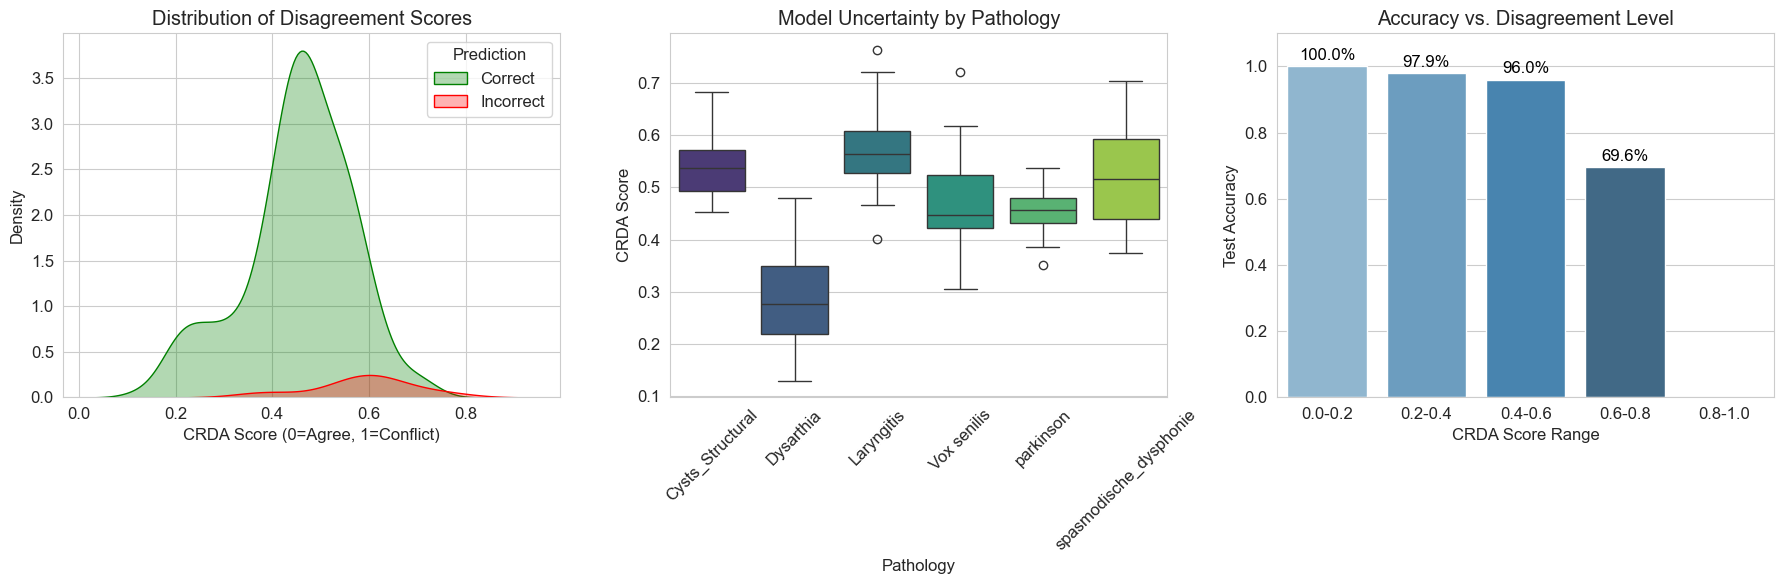


🔬 Statistical Validation (T-Test):
Mean Score (Correct): 0.4538
Mean Score (Wrong):   0.5868
P-Value: 3.6793e-04
✅ Result is Statistically Significant! (p < 0.05)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for academic papers
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---------------- PLOT 1: DISAGREEMENT DISTRIBUTION ----------------
# Hypothesis: Wrong predictions (False) should be shifted to the right (Higher Disagreement)
sns.kdeplot(
    data=crda_df, 
    x='disagreement_score', 
    hue='is_correct', 
    fill=True, 
    palette={True: 'green', False: 'red'}, 
    alpha=0.3, 
    ax=axes[0]
)
axes[0].set_title("Distribution of Disagreement Scores")
axes[0].set_xlabel("CRDA Score (0=Agree, 1=Conflict)")
axes[0].set_ylabel("Density")
# Fix the legend order
axes[0].legend(title="Prediction", labels=["Correct", "Incorrect"])

# ---------------- PLOT 2: DISAGREEMENT BY DISEASE ----------------
# Hypothesis: Spasmodic Dysphonia and Laryngitis should have higher scores than Dysarthia
sns.boxplot(
    data=crda_df, 
    x='true_class', 
    y='disagreement_score', 
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Model Uncertainty by Pathology")
axes[1].set_xlabel("Pathology")
axes[1].set_ylabel("CRDA Score")
axes[1].tick_params(axis='x', rotation=45)

# ---------------- PLOT 3: ACCURACY VS UNCERTAINTY ----------------
# Bin the disagreement scores and calculate accuracy per bin
# Low Disagreement -> High Accuracy?
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
crda_df['score_bin'] = pd.cut(crda_df['disagreement_score'], bins=bins, labels=labels)

bin_acc = crda_df.groupby('score_bin')['is_correct'].mean().reset_index()

sns.barplot(
    data=bin_acc, 
    x='score_bin', 
    y='is_correct', 
    palette="Blues_d",
    ax=axes[2]
)
axes[2].set_title("Accuracy vs. Disagreement Level")
axes[2].set_xlabel("CRDA Score Range")
axes[2].set_ylabel("Test Accuracy")
axes[2].set_ylim(0, 1.1)

# Add value labels
for index, row in bin_acc.iterrows():
    if not pd.isna(row['is_correct']):
        axes[2].text(index, row['is_correct'] + 0.02, f"{row['is_correct']*100:.1f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

# ---------------- STATISTICAL TEST ----------------
# Prove the difference is significant (t-test)
from scipy.stats import ttest_ind

correct_scores = crda_df[crda_df['is_correct'] == True]['disagreement_score']
wrong_scores = crda_df[crda_df['is_correct'] == False]['disagreement_score']

t_stat, p_val = ttest_ind(correct_scores, wrong_scores, equal_var=False)

print(f"\n🔬 Statistical Validation (T-Test):")
print(f"Mean Score (Correct): {correct_scores.mean():.4f}")
print(f"Mean Score (Wrong):   {wrong_scores.mean():.4f}")
print(f"P-Value: {p_val:.4e}")
if p_val < 0.05:
    print("✅ Result is Statistically Significant! (p < 0.05)")
else:
    print("❌ Result is not significant.")

✅ Selected Case A (Confident): Index 39 | Dysarthia | Score: 0.1296
⚠️ Selected Case B (Ambiguous): Index 97 | True: Laryngitis -> Pred: Vox senilis | Score: 0.7630


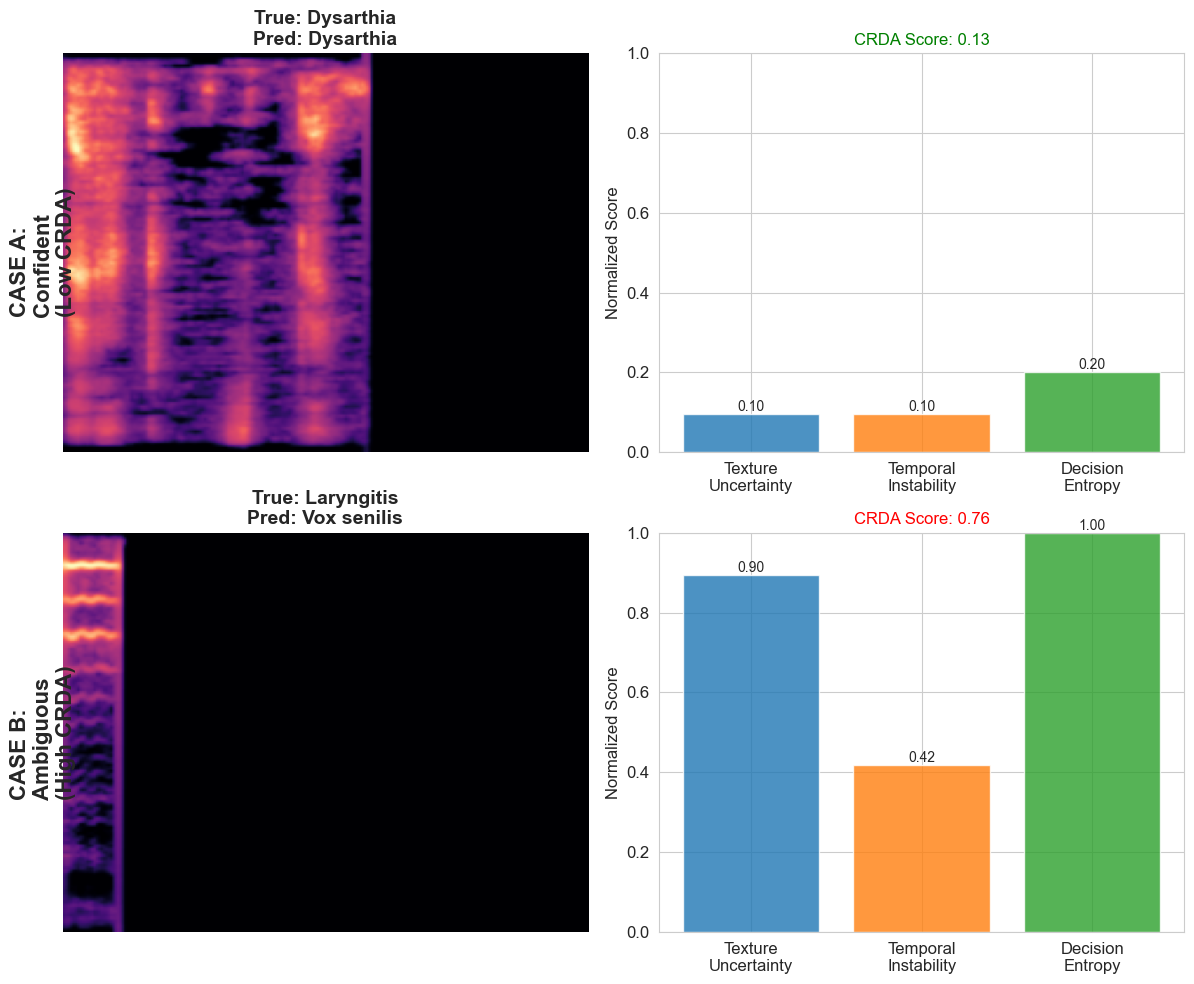

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import librosa
import librosa.display

# ---------------- 1. FIND SAMPLES ----------------
# We need one "Hero" (Low Score, Correct) and one "Villain" (High Score, Wrong)

# Case A: Low Score + Correct (The Ideal)
# We sort by score ascending and pick the first one that is Correct
low_crda_sample = crda_df[crda_df['is_correct'] == True].sort_values('disagreement_score').iloc[0]
idx_low = low_crda_sample.name  # The original index in the dataset

# Case B: High Score + Wrong (The Failure Mode)
# We sort by score descending and pick the first one that is Wrong
high_crda_sample = crda_df[crda_df['is_correct'] == False].sort_values('disagreement_score', ascending=False).iloc[0]
idx_high = high_crda_sample.name

print(f"✅ Selected Case A (Confident): Index {idx_low} | {low_crda_sample['true_class']} | Score: {low_crda_sample['disagreement_score']:.4f}")
print(f"⚠️ Selected Case B (Ambiguous): Index {idx_high} | True: {high_crda_sample['true_class']} -> Pred: {high_crda_sample['pred_class']} | Score: {high_crda_sample['disagreement_score']:.4f}")

# ---------------- 2. PLOTTING FUNCTION ----------------
def plot_case_study(sample_row, dataset, index, ax_spec, ax_bars):
    # Get the image/spectrogram
    img_tensor, _ = dataset[index]
    # Convert tensor (C, H, W) to numpy (H, W) for plotting
    # We take the mean of the channels to get a single spectrogram
    spec = img_tensor.mean(dim=0).cpu().numpy()
    
    # 1. Plot Spectrogram
    ax_spec.imshow(spec, cmap='magma', origin='lower', aspect='auto')
    ax_spec.set_title(f"True: {sample_row['true_class']}\nPred: {sample_row['pred_class']}", fontsize=14, fontweight='bold')
    ax_spec.axis('off')
    
    # 2. Plot Reasoning Signals (Bar Chart)
    # We plot the NORMALIZED signals involved in the calculation
    # Recall: D = a*(1-CNN) + b*Temp + c*Ent
    # So we plot (1-CNN), Temporal, and Entropy to show "Contributions to Disagreement"
    
    signals = [
        1.0 - sample_row['norm_cnn'],  # Texture Uncertainty
        sample_row['norm_temp'],       # Temporal Instability
        sample_row['norm_ent']         # Decision Entropy
    ]
    labels = ['Texture\nUncertainty', 'Temporal\nInstability', 'Decision\nEntropy']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
    
    bars = ax_bars.bar(labels, signals, color=colors, alpha=0.8)
    ax_bars.set_ylim(0, 1.0)
    ax_bars.set_ylabel("Normalized Score")
    ax_bars.set_title(f"CRDA Score: {sample_row['disagreement_score']:.2f}", fontsize=12, color='red' if sample_row['disagreement_score'] > 0.5 else 'green')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax_bars.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# ---------------- 3. EXECUTE PLOT ----------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot Case A (Low Disagreement)
plot_case_study(low_crda_sample, test_ds, idx_low, axes[0, 0], axes[0, 1])
axes[0, 0].text(-0.1, 0.5, "CASE A:\nConfident\n(Low CRDA)", transform=axes[0, 0].transAxes, 
                fontsize=16, fontweight='bold', va='center', rotation=90)

# Plot Case B (High Disagreement)
plot_case_study(high_crda_sample, test_ds, idx_high, axes[1, 0], axes[1, 1])
axes[1, 0].text(-0.1, 0.5, "CASE B:\nAmbiguous\n(High CRDA)", transform=axes[1, 0].transAxes, 
                fontsize=16, fontweight='bold', va='center', rotation=90)

plt.tight_layout()
plt.show()